# 1.1 Quantizer — 실수 파형을 `int16` 으로

## 이 노트북이 답하는 질문

SCALib 의 모든 분석기는 파형을 **`int16`** 으로 받는다. 그런데 오실로스코프가 주는 값은
실수다. **어떻게 정수로 옮겨야 정보를 잃지 않는가?**

`scalib.preprocessing.Quantizer` 가 그 변환을 맡는다.

| | |
|---|---|
| 입력 | `/explore` (5,000장) |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (누설 지점을 기준으로 검증하므로) |

## 왜 그냥 곱해서 반올림하면 안 되는가

`int16` 이 담을 수 있는 범위는 −32,768 ~ 32,767 이다. 잘못될 수 있는 방향은 둘이다.

| 실수 | 결과 |
|------|------|
| 배율이 너무 작다 | 파형이 몇 개 정수 계단에만 걸린다. **양자화 잡음이 신호를 덮는다** |
| 배율이 너무 크다 | 범위를 넘는 값이 잘린다(clipping) |

두 번째는 흔히 "잘리면 정보가 사라진다" 고 뭉뚱그려 말하지만, **§2 에서 실측해 보면
그렇게 단순하지 않다.** 포화율이 23% 여도 SNR 이 그대로인 구간이 있다.
이 노트북은 그 경계가 어디인지를 숫자로 보인다.

`Quantizer` 는 학습용 파형에서 적절한 이동(shift)과 배율(scale)을 **추정**해 이 줄타기를 대신한다.

$$ \text{quantized} = \mathrm{Round}\big((x - \text{shift}) \times \text{scale}\big) $$

## 두 가지 추정 방식

| `QuantFitMethod` | 방식 | 성격 |
|------------------|------|------|
| `bounds(margin)` | 학습 파형의 **최소·최대**를 범위에 맞춘다 | 이상치 하나에 배율이 좌우된다 |
| `moment(nstd)` | **평균 ± nstd·표준편차**를 범위에 맞춘다 | 이상치에 강하다. 꼬리가 잘릴 수 있다 |

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling  100000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
d = load_group("explore", n=2000)
raw_i16 = d["t"]
scale_attr = d["attrs"]["trace_scale"]

# 데이터셋은 ADC 코드 스케일 int16 으로 저장돼 있다. 이 노트북의 주제가 "실수 → 정수"
# 이므로, 저장 시 곱했던 값으로 나누어 장비가 주던 실수 파형을 복원한다.
# (이 왕복은 무손실이다 — 0.0 노트북 §8 참조)
traces_f = raw_i16.astype(np.float64) / scale_attr

print("복원한 실수 파형:", traces_f.shape, traces_f.dtype)
print("  범위 [%.5f, %.5f]" % (traces_f.min(), traces_f.max()))
print("  풀스케일(±0.5) 대비 %.1f%% 사용" % (100 * np.abs(traces_f).max() / 0.5))

복원한 실수 파형: (2000, 33172) float64
  범위 [-0.19092, 0.17847]
  풀스케일(±0.5) 대비 38.2% 사용


---
## 1. `Quantizer` API

| 단계 | 코드 |
|:----:|------|
| 학습 | `q = Quantizer.fit(traces_float, method)` |
| 변환 | `q.quantize(traces_float, clip=True)` |

`fit` 은 **클래스 메서드**다(인스턴스를 먼저 만들지 않는다). 학습에 쓰는 파형은 일부만으로
충분하며, 같은 측정 설정의 파형이면 된다.

`clip=True` 를 주면 범위를 넘는 값을 `int16` 경계로 자른다. `False` 면 넘칠 때 예외가 난다 —
**얼마나 잘리는지 모르는 채 넘어가는 것보다 낫다.**

In [3]:
from scalib.preprocessing import Quantizer, QuantFitMethod

q_bounds = Quantizer.fit(traces_f, QuantFitMethod.bounds(margin=1.0))
q_moment = Quantizer.fit(traces_f, QuantFitMethod.moment(nstd=6.0))

qb = q_bounds.quantize(traces_f, clip=True)
qm = q_moment.quantize(traces_f, clip=True)

print("방식        dtype    최소      최대     범위사용률   포화 샘플 비율")
for name, arr in (("bounds", qb), ("moment", qm)):
    sat = np.mean((arr <= -32768) | (arr >= 32767))
    print("  %-8s  %s  %7d  %7d    %6.1f%%      %.4f%%"
          % (name, arr.dtype, arr.min(), arr.max(),
             100 * (int(arr.max()) - int(arr.min())) / 65535, 100 * sat))

방식        dtype    최소      최대     범위사용률   포화 샘플 비율
  bounds    int16   -32768    32767     100.0%      0.1084%
  moment    int16   -32768    32767     100.0%      0.0000%


---
## 2. 변환이 정보를 지켰는가

판단 기준은 "그래프가 비슷해 보이는가" 가 아니라 **분석 결과가 유지되는가** 이다.
1.0 이 찾아 둔 누설 지점에서 SNR 을 재어, 배율을 바꿔 가며 정보가 언제 사라지는지 본다.

기대는 이렇다. 배율이 작으면 정수 계단이 성겨 양자화 잡음이 신호를 덮고, 크면 잘려서
정보가 사라진다. **실제로는 두 번째가 그렇게 단순하지 않다** — 아래 표를 보라.

In [4]:
from scalib.metrics import SNR

poi0 = int(np.load("nb_output/poi.npz")["poi"][0])   # 1.0 이 찾은 바이트0 누설 지점
y0 = sbox_out(d["p"], d["k"])[:, 0].astype(np.uint16).reshape(-1, 1)

def snr_at_poi(tr_i16):
    """누설 지점에서 잰 SNR. '정보가 남아 있는가' 의 척도."""
    s = SNR(nc=256); s.fit_u(np.ascontiguousarray(tr_i16), y0)
    return np.nan_to_num(s.get_snr()[0])[poi0]

def saturation(tr_i16, around=None):
    """int16 경계에 붙어 버린 샘플의 비율."""
    seg = tr_i16 if around is None else tr_i16[:, around - 20:around + 20]
    return np.mean((seg <= -32768) | (seg >= 32767))

print("누설 지점: 샘플 %d" % poi0)
print("진폭: 파형 전체 최대 %.4f, 누설 지점 부근 최대 %.4f"
      % (np.abs(traces_f).max(), np.abs(traces_f[:, poi0 - 20:poi0 + 20]).max()))
print()
print("배율        누설지점 포화   전체 포화   누설지점 SNR   서로 다른 정수값")
for sc in (100, 1000, 20000, 176000, 500000, 2_000_000, 10_000_000):
    q = np.clip(np.rint(traces_f * sc), -32768, 32767).astype(np.int16)
    print("%9d   %10.2f%%   %8.2f%%   %10.4f   %10d"
          % (sc, 100 * saturation(q, poi0), 100 * saturation(q),
             snr_at_poi(q), len(np.unique(q))))
print()
print("Quantizer 가 고른 배율")
print("  bounds  : SNR %.4f  (전체 포화 %.3f%%)" % (snr_at_poi(qb), 100 * saturation(qb)))
print("  moment  : SNR %.4f  (전체 포화 %.3f%%)" % (snr_at_poi(qm), 100 * saturation(qm)))
print("  원본 저장값(ADC 코드 스케일) : SNR %.4f" % snr_at_poi(raw_i16))

누설 지점: 샘플 6045
진폭: 파형 전체 최대 0.1909, 누설 지점 부근 최대 0.1287

배율        누설지점 포화   전체 포화   누설지점 SNR   서로 다른 정수값
      100         0.00%       0.00%       0.8388           38
     1000         0.00%       0.00%       1.3085          365
    20000         0.00%       0.00%       1.3090         1472
   176000         0.00%       0.00%       1.3097         1467
   500000        23.09%      26.43%       1.3097          539
  2000000        73.75%      77.42%       0.9370          137
 10000000        95.19%      95.21%       0.1730           29

Quantizer 가 고른 배율
  bounds  : SNR 1.3097  (전체 포화 0.108%)
  moment  : SNR 1.3097  (전체 포화 0.000%)
  원본 저장값(ADC 코드 스케일) : SNR 1.3097


### 표에서 읽을 것

**배율이 작을 때의 손실은 예상대로다.** 배율 100 에서는 파형 전체가 수십 개의 정수값에만
걸려 SNR 이 크게 떨어진다. 양자화 계단이 누설의 크기보다 굵어서 신호가 계단 사이에 묻힌다.

**잘림 쪽은 예상과 다르다.** 배율 500,000 은 누설 지점 부근의 23%, 파형 전체의 26%를
포화시키는데도 **SNR 이 전혀 떨어지지 않는다.** 포화가 파괴적이 되는 것은 배율을
2,000,000(포화 74%) 이상으로 올렸을 때다.

이유는 이렇다. 잘리는 것은 파형의 **극단값**이고, 누설은 그 극단값이 아니라 **중간값에 따라
달라지는 작은 변동**에 실려 있다. 그 변동이 아직 `int16` 범위 안에서 표현되는 한 SNR 은
유지된다. 변동 자체가 경계에 눌리기 시작해야 비로소 정보가 사라진다.

> **교훈: 포화율 자체는 판정 기준이 아니다.** "몇 %가 잘렸는가" 가 아니라
> "**누설을 담은 변동이 잘렸는가**" 를 물어야 하고, 그 답은 분석 결과(SNR)로만 나온다.
> 그래서 `Quantizer` 의 두 방식 모두 안전한 배율을 고르고, 검증은 SNR 로 한다.

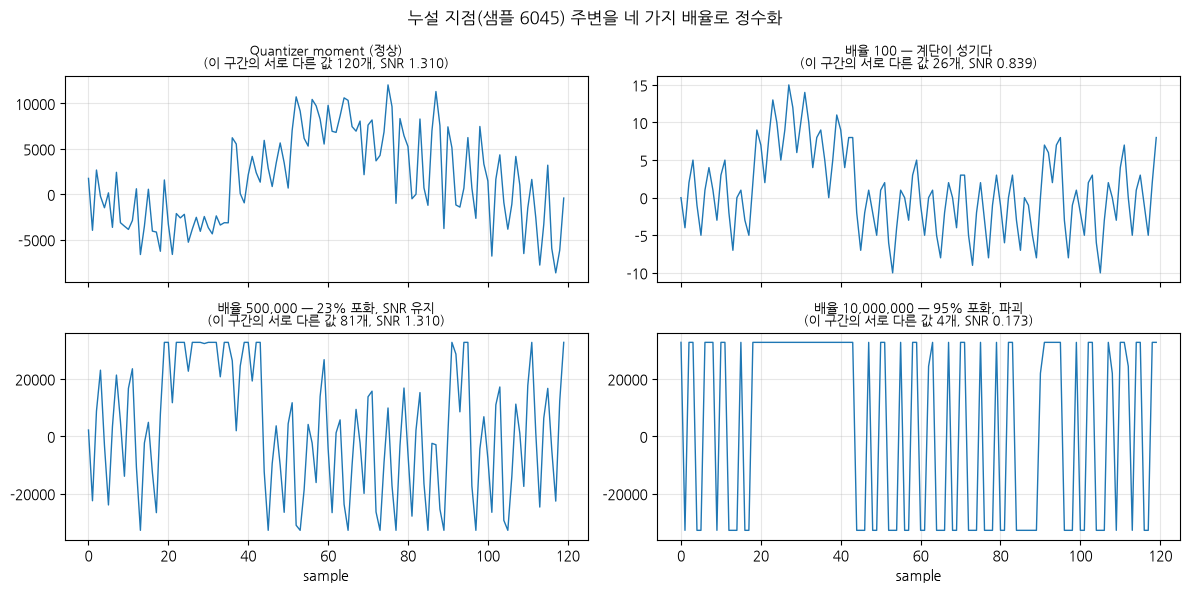

In [5]:
bad_small = np.rint(traces_f * 100).astype(np.int16)                              # 계단이 성기다
mid_clip = np.clip(np.rint(traces_f * 500000), -32768, 32767).astype(np.int16)   # 23% 포화, 정보는 남음
bad_clip = np.clip(np.rint(traces_f * 10_000_000), -32768, 32767).astype(np.int16)  # 95% 포화, 파괴

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
seg = slice(poi0 - 60, poi0 + 60)     # 누설 지점 주변을 본다
for ax, (name, arr) in zip(axes.ravel(),
                           [("Quantizer moment (정상)", qm),
                            ("배율 100 — 계단이 성기다", bad_small),
                            ("배율 500,000 — 23% 포화, SNR 유지", mid_clip),
                            ("배율 10,000,000 — 95% 포화, 파괴", bad_clip)]):
    ax.plot(arr[0, seg], lw=1.0)
    ax.set_title("%s\n(이 구간의 서로 다른 값 %d개, SNR %.3f)"
                 % (name, len(np.unique(arr[0, seg])), snr_at_poi(arr)), fontsize=9)
    ax.grid(True, alpha=0.3)
axes[1, 0].set_xlabel("sample"); axes[1, 1].set_xlabel("sample")
fig.suptitle("누설 지점(샘플 %d) 주변을 네 가지 배율로 정수화" % poi0, fontsize=12)
fig.tight_layout(); plt.show()

---
## 3. 학습 파형이 적어도 되는가

`fit` 은 전체를 다 볼 필요가 없다. 다만 **"정수값이 똑같이 나오는가" 와 "분석 결과가 같은가"
는 다른 질문**이다. 둘 다 재어 본다.

학습 파형이 적으면 추정한 shift·scale 이 조금씩 달라지므로 정수값은 당연히 달라진다.
중요한 것은 그 차이가 **SNR 을 흔드는가** 이다.

In [6]:
ref_q = Quantizer.fit(traces_f, QuantFitMethod.moment(nstd=6.0))
ref_i16 = ref_q.quantize(traces_f, clip=True)
ref_snr = snr_at_poi(ref_i16)

print("학습 장수   정수값이 동일   최대 정수 차이   누설지점 SNR   SNR 상대오차")
for m in (10, 50, 200, 1000, len(traces_f)):
    q = Quantizer.fit(traces_f[:m], QuantFitMethod.moment(nstd=6.0))
    out = q.quantize(traces_f, clip=True)
    same = np.array_equal(out, ref_i16)
    diff = int(np.abs(out.astype(np.int32) - ref_i16.astype(np.int32)).max())
    s = snr_at_poi(out)
    print("   %5d      %-6s    %10d      %8.4f      %+7.2f%%"
          % (m, same, diff, s, 100 * (s - ref_snr) / ref_snr))
print()
print("→ 정수값은 학습 장수에 따라 달라지지만(배율이 조금씩 다르므로),")
print("  누설 지점의 SNR 은 사실상 변하지 않는다. 즉 '몇 장으로 fit 했는가' 는")
print("  분석 결과에 거의 영향이 없다 — 배율이 안전 범위 안에만 있으면 된다.")

학습 장수   정수값이 동일   최대 정수 차이   누설지점 SNR   SNR 상대오차
      10      False          26731        1.3097        -0.00%
      50      False          14278        1.3097        -0.00%
     200      False           8289        1.3097        -0.00%
    1000      False           2147        1.3097        -0.00%
    2000      True               0        1.3097        +0.00%

→ 정수값은 학습 장수에 따라 달라지지만(배율이 조금씩 다르므로),
  누설 지점의 SNR 은 사실상 변하지 않는다. 즉 '몇 장으로 fit 했는가' 는
  분석 결과에 거의 영향이 없다 — 배율이 안전 범위 안에만 있으면 된다.


---
## 4. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 실수 파형을 SCALib 이 요구하는 `int16` 으로, 정보를 잃지 않고 옮긴다 |
| API | `Quantizer.fit(traces_float, method)` → `.quantize(traces_float, clip)` |
| 방식 | `QuantFitMethod.bounds(margin)` · `QuantFitMethod.moment(nstd)` |
| 검증 | 그림이 아니라 **SNR 같은 분석 결과**가 유지되는지로 판단한다 |

### 이 데이터셋에서의 실제

`0.0` 수집 노트북은 이미 무손실 변환(ADC 코드 스케일 × 32768)으로 저장하므로,
다른 노트북들은 별도 정량화 없이 `int16` 파형을 그대로 쓴다.
이 노트북은 **다른 장비·다른 저장 형식의 파형을 다룰 때** 필요한 절차를 보인다.

### 실패 시 점검

1. `quantize(clip=False)` 에서 예외 → 범위를 넘는 값이 있다. `clip=True` 로 얼마나 잘리는지 먼저 재 본다.
2. 변환 후 SNR 이 떨어진다 → 배율이 너무 작아 계단이 성기거나, 너무 커서 잘리고 있다.

다음: `2.0.Ttest.ipynb` — 누설이 있는지 없는지 판정하는 TVLA.